In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1: 16
2: 10.5
3: 24.24
4 S: 644
4 C: 168
4 Q: 77
4 Missing: 2
5: Sex
female    28.847716
male      27.276022
Name: Age, dtype: float64
6: 481
7 Alone: 30.353817504655495
7 Family: 50.56497175141242
7 Difference: 20.211154246756927
8: Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64
9 Count: 113
9 Survival rate: 53.98230088495575
10: -0.5494996199439075


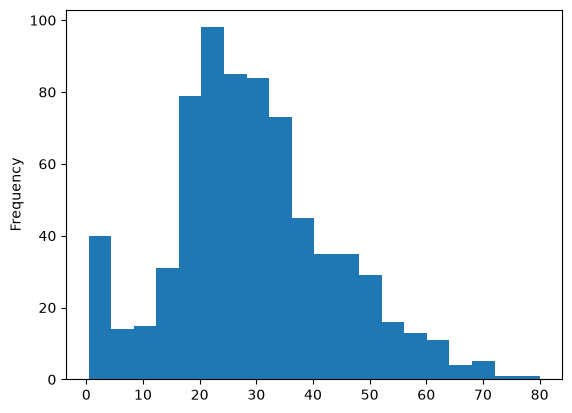

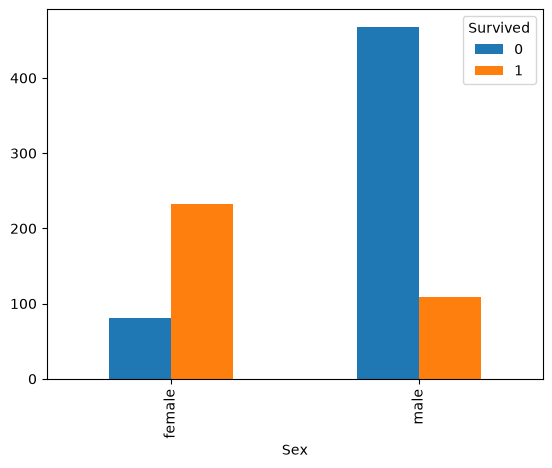

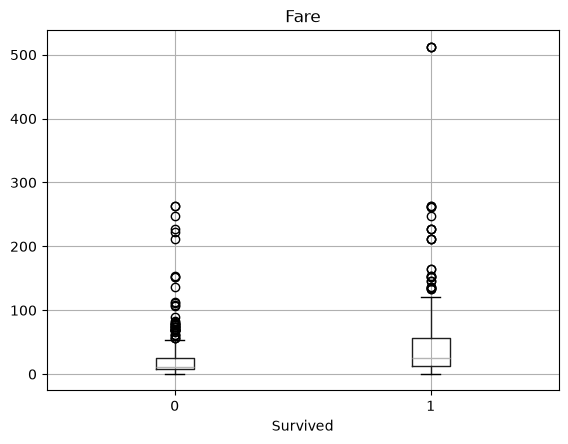

In [3]:
# 1
print("1:", df[(df["Sex"] == "female") & (df["Survived"] == 1) & (df["Age"] > 50)].shape[0])

# 2
print("2:", df[df["Survived"] == 0]["Fare"].median())

# 3
print("3:", round(df[df["Pclass"] == 3]["Survived"].mean() * 100, 2))

# 4
print("4 S:", (df["Embarked"] == "S").sum())
print("4 C:", (df["Embarked"] == "C").sum())
print("4 Q:", (df["Embarked"] == "Q").sum())
print("4 Missing:", df["Embarked"].isna().sum())

# 5
print("5:", df[df["Survived"] == 1].groupby("Sex")["Age"].mean())

# 6
print("6:", df[df["Cabin"].isna() & (df["Survived"] == 0)].shape[0])

# 7
alone = df[(df["SibSp"] == 0) & (df["Parch"] == 0)]["Survived"].mean() * 100
family = df[(df["SibSp"] > 0) | (df["Parch"] > 0)]["Survived"].mean() * 100

print("7 Alone:", alone)
print("7 Family:", family)
print("7 Difference:", abs(alone - family))

# 8
print("8:", df.groupby("Pclass")["Fare"].mean())

# 9
young = df[df["Age"] < 18]
print("9 Count:", young.shape[0])
print("9 Survival rate:", young["Survived"].mean() * 100)

# 10
print("10:", df["Fare"].corr(df["Pclass"]))

# 11
import matplotlib.pyplot as plt
df["Age"].plot.hist(bins=20)
plt.show()

# 12
df.groupby(["Sex", "Survived"]).size().unstack().plot(kind="bar")
plt.show()

# 13
df.boxplot(column="Fare", by="Survived")
plt.suptitle("")
plt.show()